# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [15]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [16]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [17]:
data = pd.read_csv('banknotes_data.csv')

In [18]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [19]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [21]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [22]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [23]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

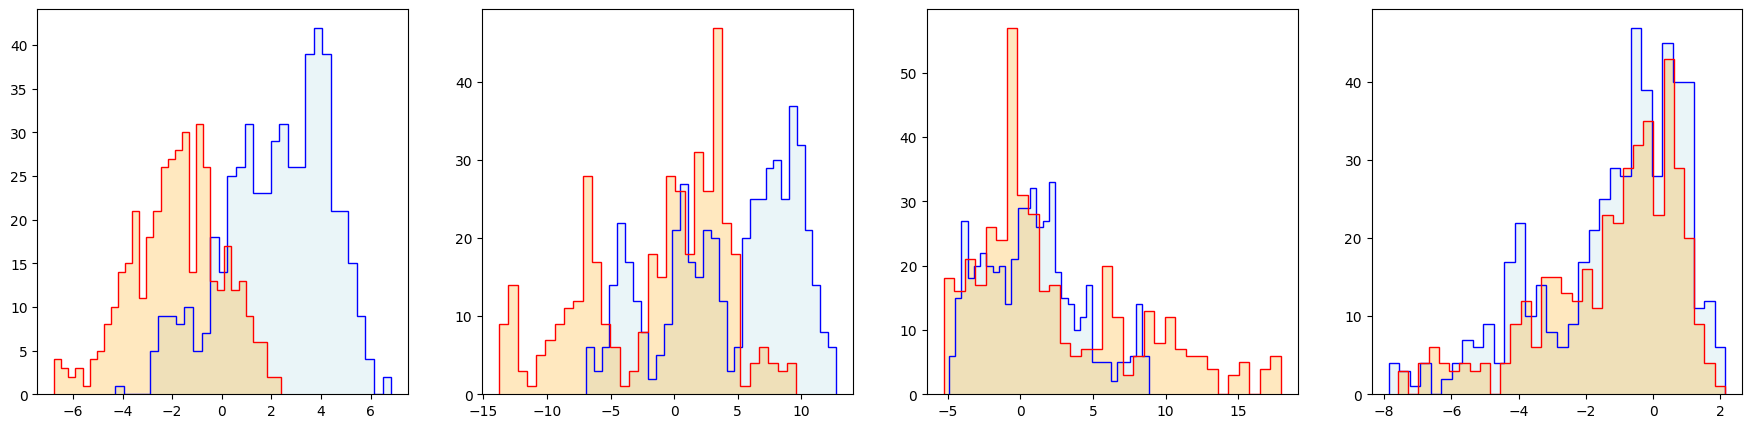

In [24]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.  

In [25]:
from sklearn.naive_bayes import GaussianNB

__Hint__ For calculating metrics and plotting ROC curves you may use functions from scikit-learn: `roc_curve`, `roc_auc_score` and `confusion matrix`. For estimating normal distribution parameters  use `norm.fit` `from scipy.stats`. Use `norm.pdf` for normal probability density function.

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

Which feature did you choose?

ROC AUC dla pojedynczych cech:
a0: 0.9443
a1: 0.7328
a2: 0.5443
a3: 0.5151

Najlepsza cecha: a0
\nConfusion matrix - TRAIN
[[0.85328185 0.14671815]
 [0.17149758 0.82850242]]
\nConfusion matrix - TEST
[[0.87692308 0.12307692]
 [0.18269231 0.81730769]]
\nROC AUC TRAIN: 0.9217
ROC AUC TEST: 0.9443


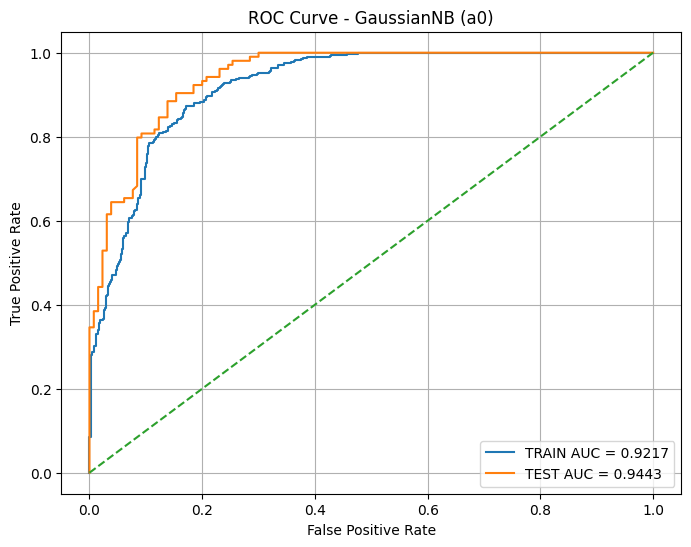

In [30]:

features = data_train.columns[:-1]

auc_scores = {}

for feature in features:
    model_tmp = GaussianNB()
    model_tmp.fit(data_train[[feature]], lbls_train)

    probs_tmp = model_tmp.predict_proba(data_test[[feature]])[:,1]
    auc_scores[feature] = roc_auc_score(lbls_test, probs_tmp)

best_feature = max(auc_scores, key=auc_scores.get)

print("ROC AUC dla pojedynczych cech:")
for k,v in auc_scores.items():
    print(f"{k}: {v:.4f}")

print(f"\nNajlepsza cecha: {best_feature}")

model = GaussianNB()
model.fit(data_train[[best_feature]], lbls_train)

train_pred = model.predict(data_train[[best_feature]])
test_pred = model.predict(data_test[[best_feature]])

train_prob = model.predict_proba(data_train[[best_feature]])[:,1]
test_prob = model.predict_proba(data_test[[best_feature]])[:,1]

cm_train = confusion_matrix(lbls_train, train_pred, normalize='true')
cm_test = confusion_matrix(lbls_test, test_pred, normalize='true')

print("\\nConfusion matrix - TRAIN")
print(cm_train)

print("\\nConfusion matrix - TEST")
print(cm_test)

auc_train = roc_auc_score(lbls_train, train_prob)
auc_test = roc_auc_score(lbls_test, test_prob)

print(f"\\nROC AUC TRAIN: {auc_train:.4f}")
print(f"ROC AUC TEST: {auc_test:.4f}")

fpr_train, tpr_train, _ = roc_curve(lbls_train, train_prob)
fpr_test, tpr_test, _ = roc_curve(lbls_test, test_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_train, tpr_train, label=f"TRAIN AUC = {auc_train:.4f}")
plt.plot(fpr_test, tpr_test, label=f"TEST AUC = {auc_test:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - GaussianNB ({best_feature})")
plt.legend()
plt.grid(True)

plt.show()


In [27]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0
